# ARC-v0.3 — Approximation-Feedback Error Amplification Probe

## Core hypothesis

ARC-v0.2 showed a strong fidelity trend:

\[
\text{PQ32} \rightarrow \text{PQ64} \rightarrow \text{SQ8}
\]

as retrieval fidelity increased:

- wrong-attractor prevalence decreased;
- final utility degradation decreased;
- oracle stopping headroom decreased;
- next-step harm became less frequent.

This suggests a more fundamental mechanism:

> Small ANN/quantization errors may be recursively amplified when retrieved results are fed
> back into the next query state.

We test this directly.

---

## Synchronized trajectories

For the same original query \(q_0\) and same feedback rule, run:

\[
q_t^{PQ32},\quad q_t^{PQ64},\quad q_t^{SQ8}.
\]

At each iteration measure:

### Query-state divergence

\[
D_q^{A,B}(t)
=
1-\cos(q_t^A,q_t^B).
\]

### Candidate-set divergence

\[
D_C^{A,B}(t)
=
1-
J(C_t^A,C_t^B).
\]

### Utility gap

\[
\Delta U^{A,B}(t)
=
U_t^B-U_t^A.
\]

If approximation error is recursively amplified, divergence should increase with
retrieval-feedback depth.

---

## Intervention experiment

We also split **search approximation** from **feedback contamination**.

### A — PQ32 self-feedback
Search with PQ32, update from PQ32 candidates.

\[
PQ32 \rightarrow PQ32\ feedback
\]

### B — PQ32 search, SQ8 feedback
The retrieval state/search remains PQ32, but the next-query feedback vector is constructed
from the matched high-fidelity SQ8 retrieval result.

\[
PQ32\ search \rightarrow SQ8\ feedback
\]

### C — SQ8 self-feedback
High-fidelity control.

\[
SQ8 \rightarrow SQ8\ feedback
\]

If B substantially improves over A, feedback contamination is a causal contributor to
recursive degradation.

---

## Protocol

- FEVER FIT only
- 1,500 fixed queries
- reuse existing cached PQ32 / PQ64 / SQ8 indexes from ARC-v0.2
- reuse v0.2 feedback configurations
- 4 feedback rounds
- no DEV / TEST retrieval
- no LLM
- no learned controller

This is a mechanism experiment, not a model-selection experiment.


In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
from pathlib import Path
from datetime import datetime
import json, sys, subprocess, os, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260816
DIM = 384
TOP_RETRIEVE = 100
TOP_K = 10
MAX_ROUNDS = 4

NLIST = 4096
NPROBE = 64

ROOT = Path(
    "/content/drive/MyDrive/"
    "hc-rars-fever-5m-untouched-confirmation-v1"
)

CORPUS_MEMMAP = ROOT / "stage1/corpus_embeddings.float16.memmap"
QUERY_EMB = ROOT / "stage1/query_embeddings_v2.float32.npy"
QUERY_IDS = ROOT / "stage1/query_ids.utf8.txt"
SPLIT_MANIFEST = ROOT / "stage1/official_split_manifest.json"
FIT_QRELS = ROOT / "stage2/fit_qrels_rows.csv"

ARC_ROOT = Path(
    "/content/drive/MyDrive/rag-pq-checkpoints/arc-v0"
)

CACHE_ROOT = Path(
    "/content/drive/MyDrive/rag-pq-checkpoints/arc-index-cache"
)

V02_RUNS = sorted(
    [
        p for p in ARC_ROOT.glob("retriever-condition-replication-v02-*")
        if (p / "report.json").is_file()
    ],
    key=lambda p: p.stat().st_mtime
)

if not V02_RUNS:
    raise FileNotFoundError(
        "No completed ARC-v0.2 run found."
    )

V02_RUN = V02_RUNS[-1]

OUT = ARC_ROOT / (
    "error-amplification-v03-"
    + datetime.now().strftime("%Y%m%d-%H%M%S")
)
OUT.mkdir(parents=True, exist_ok=True)

print("Source v0.2:", V02_RUN)
print("Output:", OUT)


Source v0.2: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/retriever-condition-replication-v02-20260815-192204
Output: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/error-amplification-v03-20260815-201450


In [3]:
def run(cmd):
    print("$", " ".join(map(str, cmd)))
    subprocess.run(list(map(str, cmd)), check=True)

run([
    sys.executable, "-m", "pip", "install", "-q",
    "faiss-cpu==1.12.0",
    "psutil",
    "pyarrow",
    "scikit-learn",
])

import faiss
import psutil

PROCESS = psutil.Process(os.getpid())

def ram_status(label=""):
    vm = psutil.virtual_memory()
    rss = PROCESS.memory_info().rss / 1024**3
    print(
        f"[RAM] {label:<30} "
        f"RSS={rss:6.2f} GB | "
        f"available={vm.available/1024**3:6.2f} GB | "
        f"used={vm.percent:5.1f}%"
    )

print("Faiss:", faiss.__version__)
ram_status("startup")


$ /usr/bin/python3 -m pip install -q faiss-cpu==1.12.0 psutil pyarrow scikit-learn
Faiss: 1.12.0
[RAM] startup                        RSS=  0.17 GB | available= 11.43 GB | used=  9.8%


## 1. Load FEVER artifacts


In [4]:
size_bytes = CORPUS_MEMMAP.stat().st_size
bytes_per_row = DIM * np.dtype(np.float16).itemsize
assert size_bytes % bytes_per_row == 0

n_docs = size_bytes // bytes_per_row
assert n_docs == 5_416_568

docs = np.memmap(
    CORPUS_MEMMAP,
    dtype=np.float16,
    mode="r",
    shape=(n_docs, DIM),
)

query_embeddings = np.load(
    QUERY_EMB,
    mmap_mode="r",
)
assert query_embeddings.shape == (123_142, DIM)

with open(QUERY_IDS, "r", encoding="utf-8") as f:
    query_ids = [x.strip() for x in f if x.strip()]

query_row = {
    qid: i
    for i, qid in enumerate(query_ids)
}

with open(SPLIT_MANIFEST, "r", encoding="utf-8") as f:
    split = json.load(f)

fit_ids = [str(x).strip() for x in split["fit_query_ids"]]
assert split["test_retrieval_performed"] is False
assert split["test_relevance_values_accessed"] is False

fit_rows = np.array(
    [query_row[q] for q in fit_ids],
    dtype=np.int64,
)

fit_qrels_df = pd.read_csv(FIT_QRELS)
fit_qrels_df["query-id"] = fit_qrels_df["query-id"].astype(str)

fit_qrels = {}

for qid, g in fit_qrels_df.groupby("query-id"):
    rel = g[g["score"] > 0]["corpus-row"].astype(np.int64)
    fit_qrels[str(qid)] = set(rel.tolist())

print("corpus:", docs.shape)
print("fit:", len(fit_rows))
print("qrels:", len(fit_qrels))


corpus: (5416568, 384)
fit: 20000
qrels: 20000


## 2. Recover v0.2 query sample and feedback configs


In [5]:
with open(V02_RUN / "report.json", "r", encoding="utf-8") as f:
    v02_report = json.load(f)

selected_configs = v02_report["design"]["feedback_configs"]

print("Feedback configs:")
for c in selected_configs:
    print(c)

# Recover the exact paired query sample from one saved trajectory.
pq32_path = V02_RUN / "ivfpq32_trajectories.parquet"

if not pq32_path.is_file():
    raise FileNotFoundError(pq32_path)

tmp = pd.read_parquet(
    pq32_path,
    columns=["query_id","query_row"],
)

sample_df = (
    tmp
    .drop_duplicates("query_id")
    .sort_values("query_id")
)

replication_qids = sample_df["query_id"].astype(str).tolist()
replication_rows = sample_df["query_row"].astype(np.int64).to_numpy()

print("Paired queries:", len(replication_rows))
assert len(replication_rows) > 0


Feedback configs:
{'method': 'mean', 'k': 20, 'alpha': 0.3, 'temperature': None}
{'method': 'softmax', 'k': 5, 'alpha': 0.5, 'temperature': 0.1}
Paired queries: 1500


## 3. Load cached PQ32 / PQ64 / SQ8 indexes


In [6]:
def find_index(pattern):
    matches = sorted(
        CACHE_ROOT.glob(pattern),
        key=lambda p: p.stat().st_mtime,
    )
    if not matches:
        raise FileNotFoundError(
            f"No cached index matching {pattern}"
        )
    return matches[-1]

INDEX_PATHS = {
    "ivfpq32": find_index(
        "fever5m-bge-small-ivfpq-nlist4096-m32-nbits8-seed20260816.faiss"
    ),
    "ivfpq64": find_index(
        "fever5m-bge-small-ivfpq-nlist4096-m64-nbits8-seed20260816.faiss"
    ),
    "ivfsq8": find_index(
        "fever5m-bge-small-ivfsq8-nlist4096-seed20260816.faiss"
    ),
}

for k,v in INDEX_PATHS.items():
    print(k, "->", v)


ivfpq32 -> /content/drive/MyDrive/rag-pq-checkpoints/arc-index-cache/fever5m-bge-small-ivfpq-nlist4096-m32-nbits8-seed20260816.faiss
ivfpq64 -> /content/drive/MyDrive/rag-pq-checkpoints/arc-index-cache/fever5m-bge-small-ivfpq-nlist4096-m64-nbits8-seed20260816.faiss
ivfsq8 -> /content/drive/MyDrive/rag-pq-checkpoints/arc-index-cache/fever5m-bge-small-ivfsq8-nlist4096-seed20260816.faiss


## 4. Core helpers


In [7]:
def normalize_rows(x):
    x = np.asarray(x, np.float32)
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(n, 1e-12)

def evaluate_one(qid, ranked_ids, k=10):
    relset = fit_qrels.get(str(qid), set())
    ranked = ranked_ids[:k]

    hits = np.array(
        [1.0 if int(d) in relset else 0.0 for d in ranked],
        dtype=np.float32,
    )

    recall = float(
        hits.sum() / max(len(relset), 1)
    )

    hitpos = np.flatnonzero(hits)
    mrr = float(
        1.0/(hitpos[0]+1)
    ) if len(hitpos) else 0.0

    discounts = 1.0/np.log2(np.arange(2,k+2))
    dcg = float((hits*discounts).sum())
    ideal = min(len(relset), k)
    idcg = float(discounts[:ideal].sum()) if ideal else 0.0
    ndcg = float(dcg/idcg) if idcg > 0 else 0.0

    return recall, mrr, ndcg

def feedback_vector(ids, scores, config):
    k = int(config["k"])
    dids = np.asarray(ids[:k], np.int64)
    x = np.asarray(docs[dids], dtype=np.float32)

    if config["method"] == "mean":
        f = x.mean(axis=0)

    elif config["method"] == "softmax":
        temp = float(config["temperature"])
        z = np.asarray(scores[:k], np.float64)/temp
        z -= z.max()
        w = np.exp(np.clip(z,-60,60))
        w /= np.maximum(w.sum(),1e-12)
        f = (x*w[:,None]).sum(axis=0)

    else:
        raise ValueError(config["method"])

    f = f.astype(np.float32)
    return f/max(np.linalg.norm(f),1e-12)

def anchored_update(q0, f, alpha):
    q = ((1-float(alpha))*q0 + float(alpha)*f).astype(np.float32)
    return q/max(np.linalg.norm(q),1e-12)

def jaccard_rows(a,b):
    vals = np.empty(len(a),dtype=np.float32)
    for i in range(len(a)):
        A=set(map(int,a[i]))
        B=set(map(int,b[i]))
        vals[i]=len(A&B)/max(len(A|B),1)
    return vals

def cosine_distance_rows(a,b):
    a = normalize_rows(a)
    b = normalize_rows(b)
    return 1.0 - np.sum(a*b,axis=1)


## 5. Run a self-feedback trajectory and retain query states

Unlike v0.2, this function explicitly stores:

- \(q_t\)
- candidate IDs
- scores
- utility

at every iteration, so trajectories can be directly paired across retrievers.


In [8]:
def run_self_feedback(index, condition, config):
    index.nprobe = NPROBE

    q0 = normalize_rows(
        np.asarray(
            query_embeddings[replication_rows],
            dtype=np.float32,
        )
    )

    qt = q0.copy()

    states = []

    for t in range(MAX_ROUNDS+1):
        print(
            condition,
            config["method"],
            "t=",t,
        )

        scores, ids = index.search(
            np.ascontiguousarray(qt,np.float32),
            TOP_RETRIEVE,
        )

        recall = np.empty(len(qt),dtype=np.float32)
        mrr = np.empty(len(qt),dtype=np.float32)
        ndcg = np.empty(len(qt),dtype=np.float32)

        for i,qid in enumerate(replication_qids):
            recall[i],mrr[i],ndcg[i] = evaluate_one(
                qid,
                ids[i],
                TOP_K,
            )

        states.append({
            "q": qt.copy(),
            "scores": scores.copy(),
            "ids": ids.copy(),
            "recall": recall,
            "mrr": mrr,
            "ndcg": ndcg,
        })

        if t < MAX_ROUNDS:
            qnext = np.empty_like(qt)

            for i in range(len(qt)):
                f = feedback_vector(
                    ids[i],
                    scores[i],
                    config,
                )

                qnext[i] = anchored_update(
                    q0[i],
                    f,
                    config["alpha"],
                )

            qt = qnext

    return states


## 6. Run synchronized PQ32 / PQ64 / SQ8 trajectories


In [9]:
all_states = {}

for condition in ["ivfpq32","ivfpq64","ivfsq8"]:
    print("="*100)
    print("CONDITION:",condition)

    index = faiss.read_index(
        str(INDEX_PATHS[condition])
    )
    index.nprobe = NPROBE

    for ci, config in enumerate(selected_configs):
        key = (
            condition,
            config["method"],
            int(config["k"]),
            float(config["alpha"]),
            None if config.get("temperature") is None
            else float(config["temperature"]),
        )

        all_states[key] = run_self_feedback(
            index,
            condition,
            config,
        )

    del index
    gc.collect()
    ram_status(f"released {condition}")

print("Finished self-feedback trajectories.")


CONDITION: ivfpq32
ivfpq32 mean t= 0
ivfpq32 mean t= 1
ivfpq32 mean t= 2
ivfpq32 mean t= 3
ivfpq32 mean t= 4
ivfpq32 softmax t= 0
ivfpq32 softmax t= 1
ivfpq32 softmax t= 2
ivfpq32 softmax t= 3
ivfpq32 softmax t= 4
[RAM] released ivfpq32               RSS=  0.88 GB | available= 11.01 GB | used= 13.1%
CONDITION: ivfpq64
ivfpq64 mean t= 0
ivfpq64 mean t= 1
ivfpq64 mean t= 2
ivfpq64 mean t= 3
ivfpq64 mean t= 4
ivfpq64 softmax t= 0
ivfpq64 softmax t= 1
ivfpq64 softmax t= 2
ivfpq64 softmax t= 3
ivfpq64 softmax t= 4
[RAM] released ivfpq64               RSS=  1.02 GB | available= 10.99 GB | used= 13.2%
CONDITION: ivfsq8
ivfsq8 mean t= 0
ivfsq8 mean t= 1
ivfsq8 mean t= 2
ivfsq8 mean t= 3
ivfsq8 mean t= 4
ivfsq8 softmax t= 0
ivfsq8 softmax t= 1
ivfsq8 softmax t= 2
ivfsq8 softmax t= 3
ivfsq8 softmax t= 4
[RAM] released ivfsq8                RSS=  1.35 GB | available= 10.47 GB | used= 17.4%
Finished self-feedback trajectories.


## 7. Direct trajectory-divergence analysis


In [10]:
pair_rows = []

pairs = [
    ("ivfpq32","ivfpq64"),
    ("ivfpq32","ivfsq8"),
    ("ivfpq64","ivfsq8"),
]

for config in selected_configs:
    ckey = (
        config["method"],
        int(config["k"]),
        float(config["alpha"]),
        None if config.get("temperature") is None
        else float(config["temperature"]),
    )

    for A,B in pairs:
        SA = all_states[(A,*ckey)]
        SB = all_states[(B,*ckey)]

        for t in range(MAX_ROUNDS+1):
            dq = cosine_distance_rows(
                SA[t]["q"],
                SB[t]["q"],
            )

            j = jaccard_rows(
                SA[t]["ids"],
                SB[t]["ids"],
            )

            dc = 1.0-j

            du = (
                SB[t]["ndcg"]
                - SA[t]["ndcg"]
            )

            for i,qid in enumerate(replication_qids):
                pair_rows.append({
                    "query_id":qid,
                    "method":config["method"],
                    "k_feedback":config["k"],
                    "alpha":config["alpha"],
                    "temperature":(
                        np.nan if config.get("temperature") is None
                        else config["temperature"]
                    ),
                    "condition_a":A,
                    "condition_b":B,
                    "iteration":t,
                    "query_divergence":float(dq[i]),
                    "candidate_divergence":float(dc[i]),
                    "utility_gap_b_minus_a":float(du[i]),
                })

pair_df = pd.DataFrame(pair_rows)

pair_summary = (
    pair_df
    .groupby(
        ["condition_a","condition_b","iteration"],
        as_index=False,
    )
    .agg(
        mean_query_divergence=("query_divergence","mean"),
        median_query_divergence=("query_divergence","median"),
        mean_candidate_divergence=("candidate_divergence","mean"),
        mean_utility_gap=("utility_gap_b_minus_a","mean"),
        mean_abs_utility_gap=("utility_gap_b_minus_a",lambda x:float(np.mean(np.abs(x)))),
    )
)

display(pair_summary)


,condition_a,condition_b,iteration,mean_query_divergence,median_query_divergence,mean_candidate_divergence,mean_utility_gap,mean_abs_utility_gap
0,ivfpq32,ivfpq64,0,-4.748503e-08,0.000000,0.759133,0.014090,0.021190
1,ivfpq32,ivfpq64,1,1.091423e-02,0.004165,0.771606,0.025395,0.032421
2,ivfpq32,ivfpq64,2,1.260807e-02,0.005156,0.772178,0.029068,0.037538
3,ivfpq32,ivfpq64,3,1.360934e-02,0.005693,0.773403,0.030214,0.039947
4,ivfpq32,ivfpq64,4,1.419356e-02,0.005745,0.774053,0.030912,0.041777
5,ivfpq32,ivfsq8,0,-4.748503e-08,0.000000,0.754015,0.018079,0.021889
6,ivfpq32,ivfsq8,1,1.186016e-02,0.004933,0.779074,0.032242,0.035849
7,ivfpq32,ivfsq8,2,1.434558e-02,0.006516,0.783746,0.037945,0.041896
8,ivfpq32,ivfsq8,3,1.573464e-02,0.007259,0.786534,0.040427,0.044598
9,ivfpq32,ivfsq8,4,1.653451e-02,0.007585,0.787932,0.041916,0.045873


## 8. Amplification slopes


In [11]:
slope_rows = []

for (a,b),g in pair_summary.groupby(
    ["condition_a","condition_b"]
):
    x = g["iteration"].to_numpy(np.float64)

    for metric in [
        "mean_query_divergence",
        "mean_candidate_divergence",
        "mean_abs_utility_gap",
    ]:
        y = g[metric].to_numpy(np.float64)
        slope = float(
            np.polyfit(x,y,1)[0]
        )

        slope_rows.append({
            "condition_a":a,
            "condition_b":b,
            "metric":metric,
            "slope_per_iteration":slope,
            "t0":float(y[0]),
            "t_final":float(y[-1]),
            "final_over_t0":(
                float(y[-1]/y[0])
                if abs(y[0]) > 1e-12
                else np.nan
            ),
        })

slope_df = pd.DataFrame(slope_rows)
display(slope_df)


,condition_a,condition_b,metric,slope_per_iteration,t0,t_final,final_over_t0
0,ivfpq32,ivfpq64,mean_query_divergence,0.003108,-4.748503e-08,0.014194,-298906.000000
1,ivfpq32,ivfpq64,mean_candidate_divergence,0.003164,7.591334e-01,0.774053,1.019653
2,ivfpq32,ivfpq64,mean_abs_utility_gap,0.004870,2.118977e-02,0.041777,1.971561
3,ivfpq32,ivfsq8,mean_query_divergence,0.003694,-4.748503e-08,0.016535,-348204.751046
4,ivfpq32,ivfsq8,mean_candidate_divergence,0.007529,7.540154e-01,0.787932,1.044981
5,ivfpq32,ivfsq8,mean_abs_utility_gap,0.005672,2.188904e-02,0.045873,2.095719
6,ivfpq64,ivfsq8,mean_query_divergence,0.001952,-4.748503e-08,0.008803,-185375.836402
7,ivfpq64,ivfsq8,mean_candidate_divergence,0.008097,5.610329e-01,0.597779,1.065497
8,ivfpq64,ivfsq8,mean_abs_utility_gap,0.001954,8.294985e-03,0.016195,1.952339


## 9. Amplification plots


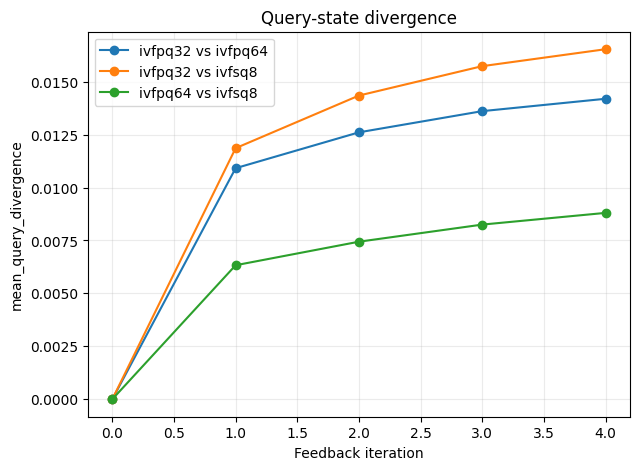

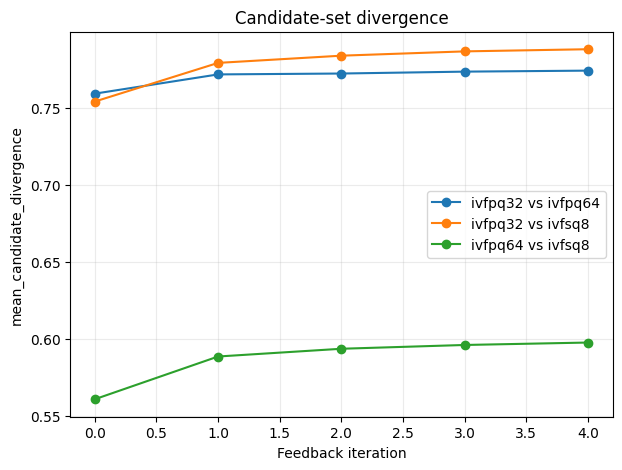

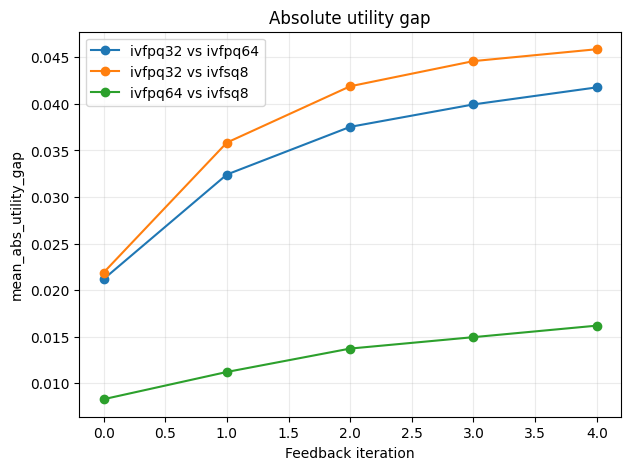

In [12]:
for metric,title in [
    ("mean_query_divergence","Query-state divergence"),
    ("mean_candidate_divergence","Candidate-set divergence"),
    ("mean_abs_utility_gap","Absolute utility gap"),
]:
    fig,ax = plt.subplots(figsize=(7,5))

    for (a,b),g in pair_summary.groupby(
        ["condition_a","condition_b"]
    ):
        ax.plot(
            g["iteration"],
            g[metric],
            marker="o",
            label=f"{a} vs {b}",
        )

    ax.set_xlabel("Feedback iteration")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=.25)
    plt.show()


## 10. Intervention: PQ32 search + SQ8 feedback

For each iteration:

- branch A searches PQ32 and constructs feedback from PQ32 results;
- branch B searches PQ32 **for its current retrieval state**, but its update vector is built
  from SQ8 retrieval results for the same current query state;
- branch C is SQ8 self-feedback.

This isolates whether high-fidelity feedback can reduce the degradation of a low-fidelity
search trajectory.

Note: branch B is a mechanism intervention, not a deployable system baseline.


In [13]:
def run_intervention(config):
    pq32 = faiss.read_index(
        str(INDEX_PATHS["ivfpq32"])
    )
    sq8 = faiss.read_index(
        str(INDEX_PATHS["ivfsq8"])
    )

    pq32.nprobe = NPROBE
    sq8.nprobe = NPROBE

    q0 = normalize_rows(
        np.asarray(
            query_embeddings[replication_rows],
            dtype=np.float32,
        )
    )

    qA = q0.copy()
    qB = q0.copy()
    qC = q0.copy()

    rows = []

    for t in range(MAX_ROUNDS+1):
        print(
            "intervention",
            config["method"],
            "t=",t
        )

        sA,idA = pq32.search(
            np.ascontiguousarray(qA,np.float32),
            TOP_RETRIEVE,
        )

        # B current retrieval state is PQ32.
        sB_search,idB_search = pq32.search(
            np.ascontiguousarray(qB,np.float32),
            TOP_RETRIEVE,
        )

        # But feedback source is SQ8 retrieval from exactly qB.
        sB_fb,idB_fb = sq8.search(
            np.ascontiguousarray(qB,np.float32),
            TOP_RETRIEVE,
        )

        sC,idC = sq8.search(
            np.ascontiguousarray(qC,np.float32),
            TOP_RETRIEVE,
        )

        for i,qid in enumerate(replication_qids):
            for branch,ids in [
                ("A_pq32_self",idA[i]),
                ("B_pq32_search_sq8_feedback",idB_search[i]),
                ("C_sq8_self",idC[i]),
            ]:
                recall,mrr,ndcg = evaluate_one(
                    qid,
                    ids,
                    TOP_K,
                )

                rows.append({
                    "query_id":qid,
                    "method":config["method"],
                    "iteration":t,
                    "branch":branch,
                    "recall@10":recall,
                    "mrr@10":mrr,
                    "ndcg@10":ndcg,
                })

        if t < MAX_ROUNDS:
            qAn = np.empty_like(qA)
            qBn = np.empty_like(qB)
            qCn = np.empty_like(qC)

            for i in range(len(q0)):
                fA = feedback_vector(
                    idA[i],
                    sA[i],
                    config,
                )
                fB = feedback_vector(
                    idB_fb[i],
                    sB_fb[i],
                    config,
                )
                fC = feedback_vector(
                    idC[i],
                    sC[i],
                    config,
                )

                qAn[i] = anchored_update(
                    q0[i],
                    fA,
                    config["alpha"],
                )
                qBn[i] = anchored_update(
                    q0[i],
                    fB,
                    config["alpha"],
                )
                qCn[i] = anchored_update(
                    q0[i],
                    fC,
                    config["alpha"],
                )

            qA,qB,qC = qAn,qBn,qCn

    del pq32,sq8
    gc.collect()

    return pd.DataFrame(rows)


In [14]:
intervention_frames = []

for config in selected_configs:
    intervention_frames.append(
        run_intervention(config)
    )

intervention_df = pd.concat(
    intervention_frames,
    ignore_index=True,
)

intervention_summary = (
    intervention_df
    .groupby(
        ["method","branch","iteration"],
        as_index=False,
    )
    .agg(
        ndcg=("ndcg@10","mean"),
        recall=("recall@10","mean"),
        mrr=("mrr@10","mean"),
    )
)

display(intervention_summary)


intervention mean t= 0
intervention mean t= 1
intervention mean t= 2
intervention mean t= 3
intervention mean t= 4
intervention softmax t= 0
intervention softmax t= 1
intervention softmax t= 2
intervention softmax t= 3
intervention softmax t= 4


,method,branch,iteration,ndcg,recall,mrr
0,mean,A_pq32_self,0,0.143306,0.156082,0.151631
1,mean,A_pq32_self,1,0.129231,0.145915,0.134347
2,mean,A_pq32_self,2,0.124895,0.142165,0.129452
3,mean,A_pq32_self,3,0.123166,0.140165,0.127903
4,mean,A_pq32_self,4,0.122840,0.140165,0.127492
5,mean,B_pq32_search_sq8_feedback,0,0.143306,0.156082,0.151631
6,mean,B_pq32_search_sq8_feedback,1,0.135289,0.153748,0.140685
7,mean,B_pq32_search_sq8_feedback,2,0.134158,0.153082,0.138990
8,mean,B_pq32_search_sq8_feedback,3,0.134014,0.152415,0.138940
9,mean,B_pq32_search_sq8_feedback,4,0.134014,0.152415,0.138940


## 11. Intervention effect sizes


In [15]:
final_iter = intervention_df["iteration"].max()

final = intervention_df[
    intervention_df.iteration == final_iter
]

pivot = final.pivot_table(
    index=["query_id","method"],
    columns="branch",
    values="ndcg@10",
    aggfunc="first",
)

pivot["B_minus_A"] = (
    pivot["B_pq32_search_sq8_feedback"]
    - pivot["A_pq32_self"]
)

pivot["C_minus_A"] = (
    pivot["C_sq8_self"]
    - pivot["A_pq32_self"]
)

pivot["B_recovery_fraction"] = (
    pivot["B_minus_A"]
    / np.maximum(
        np.abs(pivot["C_minus_A"]),
        1e-12,
    )
)

print("Final B - A mean nDCG:", float(pivot["B_minus_A"].mean()))
print("Final C - A mean nDCG:", float(pivot["C_minus_A"].mean()))
print("Fraction queries B > A:", float(np.mean(pivot["B_minus_A"] > 0)))

# Recovery fraction is only meaningful where C outperforms A.
valid = pivot[pivot["C_minus_A"] > 1e-12]

if len(valid):
    print(
        "Mean recovery fraction where C>A:",
        float(
            np.clip(
                valid["B_recovery_fraction"],
                -2,
                2,
            ).mean()
        )
    )


Final B - A mean nDCG: 0.02472624278712861
Final C - A mean nDCG: 0.04191590007079964
Fraction queries B > A: 0.059666666666666666
Mean recovery fraction where C>A: 0.5454379840005257


## 12. Dose-response across retrieval fidelity


In [16]:
# Reuse v0.2 condition summaries to quantify fidelity-dose response.
v02_summary = pd.read_csv(
    V02_RUN/"retriever_condition_summary.csv"
)

display(v02_summary)

dose = v02_summary.set_index("condition")

wrong_rates = [
    float(dose.loc["ivfpq32","wrong_attractor_rate"]),
    float(dose.loc["ivfpq64","wrong_attractor_rate"]),
    float(dose.loc["ivfsq8","wrong_attractor_rate"]),
]

harm_final = [
    float(dose.loc["ivfpq32","mean_final_minus_base_ndcg"]),
    float(dose.loc["ivfpq64","mean_final_minus_base_ndcg"]),
    float(dose.loc["ivfsq8","mean_final_minus_base_ndcg"]),
]

print("wrong-attractor dose response:", wrong_rates)
print("final utility dose response:", harm_final)


,condition,wrong_attractor_rate,correct_convergence_rate,saturation_rate,drift_rate,mean_final_minus_base_ndcg,mean_oracle_minus_base_ndcg,mean_oracle_stopping_headroom
0,ivfpq32,0.061667,0.008000,0.900000,0.0,-0.025517,0.002260,0.027777
1,ivfpq64,0.031333,0.007667,0.921667,0.0,-0.008695,0.002749,0.011445
2,ivfsq8,0.016000,0.011000,0.937000,0.0,-0.001681,0.002893,0.004574


wrong-attractor dose response: [0.0616666666666666, 0.0313333333333333, 0.016]
final utility dose response: [-0.0255169722695349, -0.0086953260502679, -0.0016805596775172]


## 13. ARC-v0.3 mechanism decision


In [17]:
# Main PQ32-vs-SQ8 slopes.
pq_sq = slope_df[
    (slope_df.condition_a=="ivfpq32")
    & (slope_df.condition_b=="ivfsq8")
].set_index("metric")

query_slope = float(
    pq_sq.loc[
        "mean_query_divergence",
        "slope_per_iteration"
    ]
)

candidate_slope = float(
    pq_sq.loc[
        "mean_candidate_divergence",
        "slope_per_iteration"
    ]
)

utility_gap_slope = float(
    pq_sq.loc[
        "mean_abs_utility_gap",
        "slope_per_iteration"
    ]
)

B_minus_A = float(
    pivot["B_minus_A"].mean()
)

fidelity_dose_response = (
    wrong_rates[0] > wrong_rates[1] > wrong_rates[2]
)

print("=== ARC-v0.3 ERROR AMPLIFICATION PROBE ===")
print(f"PQ32↔SQ8 query-divergence slope      : {query_slope:+.6f}/iter")
print(f"PQ32↔SQ8 candidate-divergence slope  : {candidate_slope:+.6f}/iter")
print(f"PQ32↔SQ8 abs utility-gap slope       : {utility_gap_slope:+.6f}/iter")
print(f"SQ8-feedback intervention B-A        : {B_minus_A:+.6f} nDCG")
print(f"Fidelity dose-response monotonic      : {fidelity_dose_response}")
print()

direct_amplification = (
    query_slope > 0
    and candidate_slope > 0
    and utility_gap_slope > 0
)

feedback_contamination = (
    B_minus_A > 0.002
)

if (
    direct_amplification
    and fidelity_dose_response
    and feedback_contamination
):
    decision = (
        "STRONG FEEDBACK-AMPLIFICATION GO: low- and high-fidelity retrieval trajectories "
        "diverge progressively with feedback depth, degradation follows a retrieval-fidelity "
        "dose response, and substituting high-fidelity feedback partially rescues the PQ32 "
        "trajectory. Proceed to cross-dataset replication and mitigation design."
    )

elif direct_amplification and fidelity_dose_response:
    decision = (
        "AMPLIFICATION GO, CAUSAL INTERVENTION WEAK: trajectory divergence grows with feedback "
        "depth and follows retrieval fidelity, but high-fidelity feedback substitution does not "
        "recover enough utility. The phenomenon is real, but the mechanism may involve search-state "
        "divergence beyond feedback contamination alone."
    )

elif fidelity_dose_response:
    decision = (
        "FIDELITY EFFECT WITHOUT DIRECT RECURSIVE AMPLIFICATION: lower-fidelity retrievers degrade "
        "more, but synchronized trajectory divergence does not clearly increase with depth. Do not "
        "claim recursive amplification yet."
    )

else:
    decision = (
        "AMPLIFICATION NO-GO: v0.3 does not support a clean approximation-feedback amplification "
        "mechanism. Stop this framing before cross-dataset expansion."
    )

print("DECISION:", decision)


=== ARC-v0.3 ERROR AMPLIFICATION PROBE ===
PQ32↔SQ8 query-divergence slope      : +0.003694/iter
PQ32↔SQ8 candidate-divergence slope  : +0.007529/iter
PQ32↔SQ8 abs utility-gap slope       : +0.005672/iter
SQ8-feedback intervention B-A        : +0.024726 nDCG
Fidelity dose-response monotonic      : True

DECISION: STRONG FEEDBACK-AMPLIFICATION GO: low- and high-fidelity retrieval trajectories diverge progressively with feedback depth, degradation follows a retrieval-fidelity dose response, and substituting high-fidelity feedback partially rescues the PQ32 trajectory. Proceed to cross-dataset replication and mitigation design.


## 14. Save evidence


In [18]:
pair_df.to_parquet(
    OUT/"paired_trajectory_divergence.parquet",
    index=False,
)

pair_summary.to_csv(
    OUT/"paired_trajectory_summary.csv",
    index=False,
)

slope_df.to_csv(
    OUT/"amplification_slopes.csv",
    index=False,
)

intervention_df.to_parquet(
    OUT/"feedback_intervention.parquet",
    index=False,
)

intervention_summary.to_csv(
    OUT/"feedback_intervention_summary.csv",
    index=False,
)

pivot.reset_index().to_csv(
    OUT/"feedback_intervention_final_effects.csv",
    index=False,
)

report = {
    "source_v02": str(V02_RUN),
    "queries": int(len(replication_rows)),
    "rounds": MAX_ROUNDS,
    "feedback_configs": selected_configs,
    "pq32_sq8_query_divergence_slope": query_slope,
    "pq32_sq8_candidate_divergence_slope": candidate_slope,
    "pq32_sq8_abs_utility_gap_slope": utility_gap_slope,
    "sq8_feedback_intervention_delta_ndcg": B_minus_A,
    "fidelity_wrong_attractor_rates": {
        "ivfpq32": wrong_rates[0],
        "ivfpq64": wrong_rates[1],
        "ivfsq8": wrong_rates[2],
    },
    "fidelity_dose_response_monotonic": fidelity_dose_response,
    "decision": decision,
    "test_retrieval_performed": False,
}

(OUT/"report.json").write_text(
    json.dumps(
        report,
        indent=2,
        default=float,
    ),
    encoding="utf-8",
)

print("Saved:", OUT)
print("Report:", OUT/"report.json")


Saved: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/error-amplification-v03-20260815-201450
Report: /content/drive/MyDrive/rag-pq-checkpoints/arc-v0/error-amplification-v03-20260815-201450/report.json
